Loaded 2000 samples
{'id': 'sample_0', 'title': 'Users need a Public Cloud', 'context': 'Users need a Public Cloud equivalent for transaction CJI3 to track project costs. Use App Project Cost Report (F2513) and drill down to Project Cost Report - Line Items (F2538).', 'question': 'What is the Public Cloud app equivalent of CJI3?', 'answer_text': 'Use App Project Cost Report (F2513) and drill down to Project Cost Report - Line Items (F2538).', 'answer_start': 82, 'answer_end': 177}


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 3059.16 examples/s]
Some weights of RobertaForQuestionAnswering were not initialized from the model checkpoint at roberta-base and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Training...


Epoch,Training Loss,Validation Loss
1,0.354500,0.490996
2,0.517900,0.404638
3,0.347500,0.377947


Training completed in 31334.70 seconds.


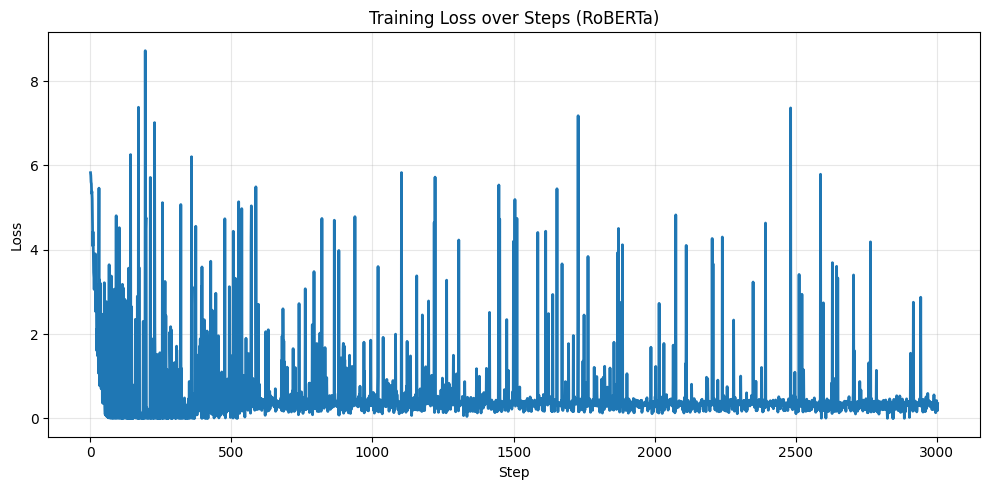

Evaluating Model...


[nltk_data] Downloading package wordnet to /home/kawkab/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kawkab/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/kawkab/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



FINAL EVALUATION RESULTS (RoBERTa)
F1 Score (Token Overlap) : 0.6144
Accuracy (Exact Match)   : 0.5612
BLEU                     : 0.5376
ROUGE-L                  : 0.6131
METEOR                   : 0.5850
Avg Confidence           : 0.3489
Avg Semantic Similarity  : 0.6337
Training Time (seconds)  : 31334.6972


In [5]:
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer
)
import evaluate
from sentence_transformers import SentenceTransformer, util
import re
import string
from collections import Counter


# ==========================================
# 1. Load and Prepare Data
# ==========================================

json_file = "version1_2_fixed_other.json"   # Change to your file

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]

flat_data = []
sample_id = 0

for item in data:
    title = item.get("title", "")

    for para in item.get("paragraphs", []):
        context = para.get("context", "")

        for qa in para.get("qas", []):

            # Skip questions without answers
            if not qa.get("answers"):
                continue

            answer = qa["answers"][0]

            flat_data.append({
                "id": qa.get("id", f"sample_{sample_id}"),
                "title": title,
                "context": context,
                "question": qa.get("question", ""),
                "answer_text": answer.get("text", ""),
                "answer_start": answer.get("answer_start", -1),
                "answer_end": answer.get("answer_end", -1)
            })

            sample_id += 1

from sklearn.model_selection import train_test_split

# Split the data: 80% train, 20% test
train_raw, test_raw = train_test_split(flat_data, test_size=0.2, random_state=42)

train_dataset = Dataset.from_list(train_raw)
test_dataset = Dataset.from_list(test_raw)

print(f"✅ Loaded {len(flat_data)} total samples")
print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Testing samples: {len(test_dataset)}")
print(train_dataset[0])

# ==========================================
# 2. Tokenization and Preprocessing
# ==========================================

# CHANGED: Use RoBERTa base model
model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


def preprocess_function(examples):
    tokenized = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length"
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")

    tokenized["start_positions"] = []
    tokenized["end_positions"] = []
    tokenized["answer_texts"] = []
    tokenized["example_id"] = []  # NEW: rebuilt per output row

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        
        # CHANGED: RoBERTa uses <s> as the CLS equivalent. 
        # tokenizer.cls_token_id handles this abstraction correctly for RoBERTa.
        cls_index = input_ids.index(tokenizer.cls_token_id)

        sample_index = sample_mapping[i]
        answer_text = examples["answer_text"][sample_index]
        answer_start_char = examples["answer_start"][sample_index]
        answer_end_char = examples["answer_end"][sample_index]

        tokenized["answer_texts"].append(answer_text)
        tokenized["example_id"].append(examples["id"][sample_index])

        sequence_ids = tokenized.sequence_ids(i)
        
        # Find the context part (sequence_ids == 1)
        # Note: In RoBERTa, there are no token_type_ids, but sequence_ids() 
        # still correctly identifies which tokens belong to question (0) vs context (1)
        try:
            context_start = sequence_ids.index(1)
            # Find last occurrence of 1
            context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)
        except ValueError:
            # If no context tokens found (rare edge case), default to CLS
            tokenized["start_positions"].append(cls_index)
            tokenized["end_positions"].append(cls_index)
            continue

        # Check if the answer is entirely within the context span of this feature
        if offsets[context_start][0] > answer_end_char or offsets[context_end][1] < answer_start_char:
            tokenized["start_positions"].append(cls_index)
            tokenized["end_positions"].append(cls_index)
        else:
            token_start = context_start
            while token_start <= context_end and offsets[token_start][0] <= answer_start_char:
                token_start += 1
            start_position = token_start - 1

            token_end = context_end
            while token_end >= context_start and offsets[token_end][1] >= answer_end_char:
                token_end -= 1
            end_position = token_end + 1

            tokenized["start_positions"].append(start_position)
            tokenized["end_positions"].append(end_position)

    return tokenized


# Tokenize train and test SEPARATELY to prevent stride leakage
cols_to_remove_train = [col for col in train_dataset.column_names if col != "answer_texts"]
tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=cols_to_remove_train)

cols_to_remove_test = [col for col in test_dataset.column_names if col != "answer_texts"]
tokenized_test = test_dataset.map(preprocess_function, batched=True, remove_columns=cols_to_remove_test)

print(f"✅ Tokenized train chunks: {len(tokenized_train)}")
print(f"✅ Tokenized test chunks: {len(tokenized_test)}")
# ==========================================
# 3. Model Initialization & Training
# ==========================================
model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)

start_train_time = time.time()

training_args = TrainingArguments(
    output_dir="./results_roberta",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none",
    use_cpu=True,
    logging_steps=1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,   # ✅ Train on the training chunks
    eval_dataset=tokenized_test,     # ✅ Validate on unseen test chunks
)

print("Starting Training...")
trainer.train()

end_train_time = time.time()
training_time = end_train_time - start_train_time
print(f"Training completed in {training_time:.2f} seconds.")

# ==========================================
# 3.5 Plot Training Loss
# ==========================================
log_history = trainer.state.log_history
steps = []
losses = []

for log in log_history:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

if steps:
    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, linewidth=2)
    plt.title("Training Loss over Steps (RoBERTa)")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig("training_loss_roberta.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    print("No loss history found to plot.")

# ==========================================
# 4. Comprehensive Evaluation Metrics (String-Based QA)
# ==========================================
print("Evaluating Model...")


def normalize_text(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def compute_qa_f1(prediction, ground_truth):
    prediction_tokens = normalize_text(prediction).split()
    ground_truth_tokens = normalize_text(ground_truth).split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    return 2 * (precision * recall) / (precision + recall)


def compute_qa_exact_match(prediction, ground_truth):
    return 1.0 if normalize_text(prediction) == normalize_text(ground_truth) else 0.0


bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

similarity_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')


def evaluate_model(model, dataset, tokenizer):
    device = torch.device("cpu")
    model.to(device)
    model.eval()

    all_preds_text = []
    all_refs_text = []
    confidences = []
    similarities = []

    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i]

            # CHANGED: RoBERTa does NOT use token_type_ids. 
            # We filter keys to only include what exists in the sample and is valid for the model.
            valid_keys = ['input_ids', 'attention_mask']
            
            inputs = {
                k: torch.tensor(v).unsqueeze(0).to(device)
                for k, v in sample.items() if k in valid_keys
            }

            outputs = model(**inputs)
            start_logits = outputs.start_logits
            end_logits = outputs.end_logits

            start_idx = torch.argmax(start_logits, dim=1).item()
            end_idx = torch.argmax(end_logits, dim=1).item()

            if end_idx < start_idx:
                end_idx = start_idx

            start_probs = torch.softmax(start_logits, dim=1)
            end_probs = torch.softmax(end_logits, dim=1)
            confidence = (start_probs[0, start_idx] * end_probs[0, end_idx]).item()
            confidences.append(confidence)

            pred_tokens = inputs['input_ids'][0, start_idx:end_idx + 1]
            pred_text = tokenizer.decode(pred_tokens, skip_special_tokens=True).strip()

            ref_text = sample['answer_texts']

            all_preds_text.append(pred_text)
            all_refs_text.append(ref_text)

            # Handle empty predictions for similarity model
            if not pred_text:
                sim_score = 0.0
            else:
                pred_emb = similarity_model.encode(pred_text, convert_to_tensor=True, device='cpu')
                ref_emb = similarity_model.encode(ref_text, convert_to_tensor=True, device='cpu')
                sim_score = util.cos_sim(pred_emb, ref_emb).item()
            
            similarities.append(sim_score)

    f1_scores = [compute_qa_f1(pred, ref) for pred, ref in zip(all_preds_text, all_refs_text)]
    em_scores = [compute_qa_exact_match(pred, ref) for pred, ref in zip(all_preds_text, all_refs_text)]

    avg_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0.0
    avg_em = sum(em_scores) / len(em_scores) if em_scores else 0.0

    bleu_score = bleu_metric.compute(predictions=all_preds_text, references=[[r] for r in all_refs_text])['bleu']
    rouge_score = rouge_metric.compute(predictions=all_preds_text, references=all_refs_text, rouge_types=["rougeL"])['rougeL']
    meteor_score = meteor_metric.compute(predictions=all_preds_text, references=all_refs_text)['meteor']

    avg_confidence = float(np.mean(confidences)) if confidences else 0.0
    avg_similarity = float(np.mean(similarities)) if similarities else 0.0

    return {
        "F1 Score (Token Overlap)": avg_f1,
        "Accuracy (Exact Match)": avg_em,
        "BLEU": bleu_score,
        "ROUGE-L": rouge_score,
        "METEOR": meteor_score,
        "Avg Confidence": avg_confidence,
        "Avg Semantic Similarity": avg_similarity,
        "Training Time (seconds)": training_time
    }


# ✅ Final evaluation ONLY on the unseen test set
results = evaluate_model(model, tokenized_test, tokenizer)
print("\n" + "=" * 45)
print("FINAL EVALUATION RESULTS (RoBERTa)")
print("=" * 45)
for metric, value in results.items():
    if isinstance(value, float):
        print(f"{metric:<25}: {value:.4f}")
    else:
        print(f"{metric:<25}: {value}")

Loaded 2000 samples
{'id': 'sample_0', 'title': 'Users need a Public Cloud', 'context': 'Users need a Public Cloud equivalent for transaction CJI3 to track project costs. Use App Project Cost Report (F2513) and drill down to Project Cost Report - Line Items (F2538).', 'question': 'What is the Public Cloud app equivalent of CJI3?', 'answer_text': 'Use App Project Cost Report (F2513) and drill down to Project Cost Report - Line Items (F2538).', 'answer_start': 82, 'answer_end': 177}


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 3051.07 examples/s]
Some weights of RobertaForQuestionAnswering were not initialized from the model checkpoint at roberta-base and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



LoRA trainable parameters:
trainable params: 296,450 || all params: 124,353,028 || trainable%: 0.2384
Starting Training...


Epoch,Training Loss,Validation Loss
1,0.254500,0.719915
2,1.977300,0.369945
3,0.000600,0.315805


Training completed in 10085.30 seconds.


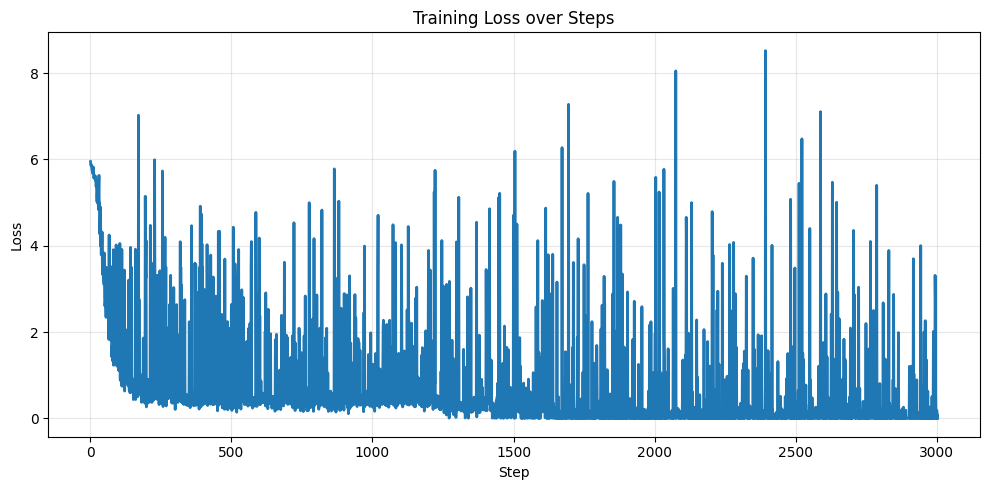

Evaluating Model...


[nltk_data] Downloading package wordnet to /home/kawkab/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kawkab/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/kawkab/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



FINAL EVALUATION RESULTS (LoRA)
F1 Score (Token Overlap) : 0.8897
Accuracy (Exact Match)   : 0.8506
BLEU                     : 0.8915
ROUGE-L                  : 0.8898
METEOR                   : 0.8862
Avg Confidence           : 0.8476
Avg Semantic Similarity  : 0.8969
Training Time (seconds)  : 10085.3018


In [13]:
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
from sentence_transformers import SentenceTransformer, util
import re
import string
from collections import Counter


# ==========================================
# 1. Load and Prepare Data
# ==========================================

json_file = "version1_2_fixed_other.json"   # Change to your file

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]

flat_data = []
sample_id = 0

for item in data:
    title = item.get("title", "")

    for para in item.get("paragraphs", []):
        context = para.get("context", "")

        for qa in para.get("qas", []):

            # Skip questions without answers
            if not qa.get("answers"):
                continue

            answer = qa["answers"][0]

            flat_data.append({
                "id": qa.get("id", f"sample_{sample_id}"),
                "title": title,
                "context": context,
                "question": qa.get("question", ""),
                "answer_text": answer.get("text", ""),
                "answer_start": answer.get("answer_start", -1),
                "answer_end": answer.get("answer_end", -1)
            })

            sample_id += 1
from sklearn.model_selection import train_test_split

# Split the 2000 samples: 80% train, 20% test
train_raw, test_raw = train_test_split(flat_data, test_size=0.2, random_state=42)

train_dataset = Dataset.from_list(train_raw)
test_dataset = Dataset.from_list(test_raw)

print(f"✅ Loaded {len(flat_data[:2000])} total samples")
print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Testing samples: {len(test_dataset)}")
print(train_dataset[0])

# ==========================================
# 2. Tokenization and Preprocessing
# ==========================================
model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


def preprocess_function(examples):
    tokenized = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length"
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")

    tokenized["start_positions"] = []
    tokenized["end_positions"] = []
    tokenized["answer_texts"] = []
    tokenized["example_id"] = []  # rebuilt per output row (fixes row-count mismatch)

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)

        sample_index = sample_mapping[i]
        answer_text = examples["answer_text"][sample_index]
        answer_start_char = examples["answer_start"][sample_index]
        answer_end_char = examples["answer_end"][sample_index]

        tokenized["answer_texts"].append(answer_text)
        tokenized["example_id"].append(examples["id"][sample_index])

        sequence_ids = tokenized.sequence_ids(i)
        context_start = sequence_ids.index(1)
        context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        if offsets[context_start][0] > answer_end_char or offsets[context_end][1] < answer_start_char:
            tokenized["start_positions"].append(cls_index)
            tokenized["end_positions"].append(cls_index)
        else:
            token_start = context_start
            while token_start <= context_end and offsets[token_start][0] <= answer_start_char:
                token_start += 1
            start_position = token_start - 1

            token_end = context_end
            while token_end >= context_start and offsets[token_end][1] >= answer_end_char:
                token_end -= 1
            end_position = token_end + 1

            tokenized["start_positions"].append(start_position)
            tokenized["end_positions"].append(end_position)

    return tokenized


# Tokenize train and test SEPARATELY to prevent stride leakage
cols_to_remove_train = [col for col in train_dataset.column_names if col != "answer_texts"]
tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=cols_to_remove_train)

cols_to_remove_test = [col for col in test_dataset.column_names if col != "answer_texts"]
tokenized_test = test_dataset.map(preprocess_function, batched=True, remove_columns=cols_to_remove_test)

print(f"✅ Tokenized train chunks: {len(tokenized_train)}")
print(f"✅ Tokenized test chunks: {len(tokenized_test)}")
# ==========================================
# 3. Model Initialization + LoRA + Training
# ==========================================
base_model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)

# ---- LoRA configuration ----
# For BERT-style encoders, LoRA is typically injected into the attention
# projection layers (query/value). task_type=QUESTION_ANS tells PEFT this
# is a QA head model so it keeps the qa_outputs layer trainable too.
lora_config = LoraConfig(
    task_type=TaskType.QUESTION_ANS,
    r=8,                       # rank of the low-rank matrices
    lora_alpha=16,             # scaling factor (commonly 2x r)
    lora_dropout=0.1,
    target_modules=["query", "value"],  # BERT attention projections
    bias="none",
)

model = get_peft_model(base_model, lora_config)

print("\nLoRA trainable parameters:")
model.print_trainable_parameters()

start_train_time = time.time()

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-4,  # LoRA typically trains well with a higher LR than full fine-tuning
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none",
    use_cpu=True,
    logging_steps=1,  # ensures loss is printed at every step/epoch
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,   # ✅ Train on the training chunks
    eval_dataset=tokenized_test,     # ✅ Validate on unseen test chunks
)
print("Starting Training...")
trainer.train()

end_train_time = time.time()
training_time = end_train_time - start_train_time
print(f"Training completed in {training_time:.2f} seconds.")

# ==========================================
# 3.5 Plot Training Loss
# ==========================================
log_history = trainer.state.log_history
steps = []
losses = []

for log in log_history:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

if steps:
    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, linewidth=2)
    plt.title("Training Loss over Steps")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save the figure
    plt.savefig("training_loss_lora-robert.png", dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()
else:
    print("No loss history found to plot.")

# ==========================================
# 4. Comprehensive Evaluation Metrics (String-Based QA)
# ==========================================
print("Evaluating Model...")


def normalize_text(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def compute_qa_f1(prediction, ground_truth):
    prediction_tokens = normalize_text(prediction).split()
    ground_truth_tokens = normalize_text(ground_truth).split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    return 2 * (precision * recall) / (precision + recall)


def compute_qa_exact_match(prediction, ground_truth):
    return 1.0 if normalize_text(prediction) == normalize_text(ground_truth) else 0.0


bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

similarity_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')


def evaluate_model(model, dataset, tokenizer):
    device = torch.device("cpu")
    model.to(device)
    model.eval()

    all_preds_text = []
    all_refs_text = []
    confidences = []
    similarities = []

    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i]

            inputs = {
                k: torch.tensor(v).unsqueeze(0).to(device)
                for k, v in sample.items() if k in ['input_ids', 'attention_mask', 'token_type_ids']
            }

            outputs = model(**inputs)
            start_logits = outputs.start_logits
            end_logits = outputs.end_logits

            start_idx = torch.argmax(start_logits, dim=1).item()
            end_idx = torch.argmax(end_logits, dim=1).item()

            if end_idx < start_idx:
                end_idx = start_idx

            start_probs = torch.softmax(start_logits, dim=1)
            end_probs = torch.softmax(end_logits, dim=1)
            confidence = (start_probs[0, start_idx] * end_probs[0, end_idx]).item()
            confidences.append(confidence)

            pred_tokens = inputs['input_ids'][0, start_idx:end_idx + 1]
            pred_text = tokenizer.decode(pred_tokens, skip_special_tokens=True).strip()

            ref_text = sample['answer_texts']

            all_preds_text.append(pred_text)
            all_refs_text.append(ref_text)

            pred_emb = similarity_model.encode(pred_text, convert_to_tensor=True, device='cpu')
            ref_emb = similarity_model.encode(ref_text, convert_to_tensor=True, device='cpu')
            sim_score = util.cos_sim(pred_emb, ref_emb).item()
            similarities.append(sim_score)

    f1_scores = [compute_qa_f1(pred, ref) for pred, ref in zip(all_preds_text, all_refs_text)]
    em_scores = [compute_qa_exact_match(pred, ref) for pred, ref in zip(all_preds_text, all_refs_text)]

    avg_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0.0
    avg_em = sum(em_scores) / len(em_scores) if em_scores else 0.0

    bleu_score = bleu_metric.compute(predictions=all_preds_text, references=[[r] for r in all_refs_text])['bleu']
    rouge_score = rouge_metric.compute(predictions=all_preds_text, references=all_refs_text, rouge_types=["rougeL"])['rougeL']
    meteor_score = meteor_metric.compute(predictions=all_preds_text, references=all_refs_text)['meteor']

    avg_confidence = float(np.mean(confidences)) if confidences else 0.0
    avg_similarity = float(np.mean(similarities)) if similarities else 0.0

    return {
        "F1 Score (Token Overlap)": avg_f1,
        "Accuracy (Exact Match)": avg_em,
        "BLEU": bleu_score,
        "ROUGE-L": rouge_score,
        "METEOR": meteor_score,
        "Avg Confidence": avg_confidence,
        "Avg Semantic Similarity": avg_similarity,
        "Training Time (seconds)": training_time
    }


# ✅ Final evaluation ONLY on the unseen test set
results = evaluate_model(model, tokenized_test, tokenizer)
print("\n" + "=" * 45)
print("FINAL EVALUATION RESULTS (LoRA)")
print("=" * 45)
for metric, value in results.items():
    if isinstance(value, float):
        print(f"{metric:<25}: {value:.4f}")
    else:
        print(f"{metric:<25}: {value}")

Loaded 2000 samples
{'id': 'sample_0', 'title': 'Users need a Public Cloud', 'context': 'Users need a Public Cloud equivalent for transaction CJI3 to track project costs. Use App Project Cost Report (F2513) and drill down to Project Cost Report - Line Items (F2538).', 'question': 'What is the Public Cloud app equivalent of CJI3?', 'answer_text': 'Use App Project Cost Report (F2513) and drill down to Project Cost Report - Line Items (F2538).', 'answer_start': 82, 'answer_end': 177}


Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 3050.85 examples/s]


Calculated total training steps: 1000


Some weights of RobertaForQuestionAnswering were not initialized from the model checkpoint at roberta-base and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



AdaLoRA trainable parameters:
trainable params: 296,642 || all params: 124,353,244 || trainable%: 0.2385
Starting Training...


Epoch,Training Loss,Validation Loss
1,0.241100,1.068287


Training completed in 5489.19 seconds.


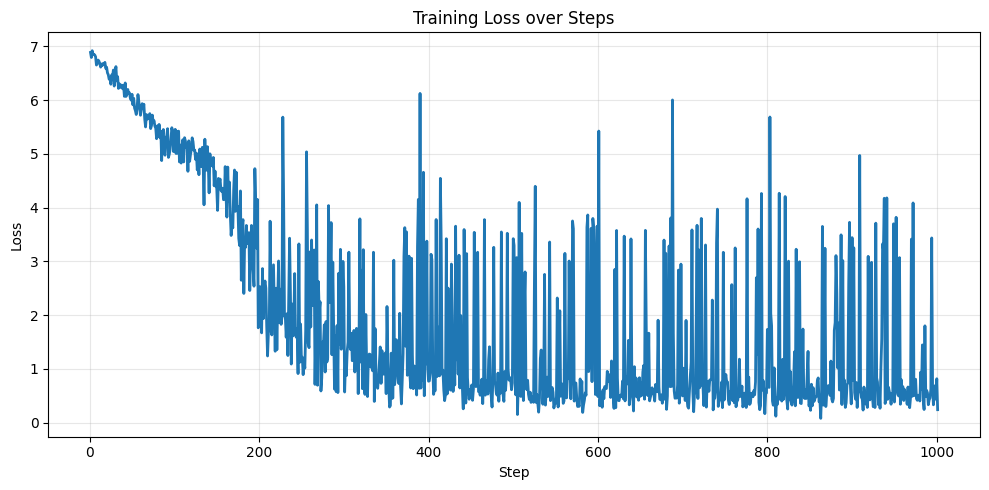

Evaluating Model...


[nltk_data] Downloading package wordnet to /home/kawkab/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kawkab/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/kawkab/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



FINAL EVALUATION RESULTS (AdaLoRA)
F1 Score (Token Overlap) : 0.3819
Accuracy (Exact Match)   : 0.2949
BLEU                     : 0.2255
ROUGE-L                  : 0.3788
METEOR                   : 0.3393
Avg Confidence           : 0.1474
Avg Semantic Similarity  : 0.3923
Training Time (seconds)  : 5489.1909


In [10]:
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer
)
from peft import AdaLoraConfig, get_peft_model, TaskType
import evaluate
from sentence_transformers import SentenceTransformer, util
import re
import string
from collections import Counter


# ==========================================
# 1. Load and Prepare Data
# ==========================================

json_file = "version1_2_fixed_other.json"   # Change to your file

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)["data"]

flat_data = []
sample_id = 0

for item in data:
    title = item.get("title", "")

    for para in item.get("paragraphs", []):
        context = para.get("context", "")

        for qa in para.get("qas", []):

            # Skip questions without answers
            if not qa.get("answers"):
                continue

            answer = qa["answers"][0]

            flat_data.append({
                "id": qa.get("id", f"sample_{sample_id}"),
                "title": title,
                "context": context,
                "question": qa.get("question", ""),
                "answer_text": answer.get("text", ""),
                "answer_start": answer.get("answer_start", -1),
                "answer_end": answer.get("answer_end", -1)
            })

            sample_id += 1

from sklearn.model_selection import train_test_split

train_raw, test_raw = train_test_split(flat_data, test_size=0.2, random_state=42)

train_dataset = Dataset.from_list(train_raw)
test_dataset = Dataset.from_list(test_raw)

print(f"✅ Loaded {len(flat_data[:2000])} total samples")
print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Testing samples: {len(test_dataset)}")
print(train_dataset[0])



# ==========================================
# 2. Tokenization and Preprocessing
# ==========================================
model_checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


def preprocess_function(examples):
    tokenized = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length"
    )

    sample_mapping = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized.pop("offset_mapping")

    tokenized["start_positions"] = []
    tokenized["end_positions"] = []
    tokenized["answer_texts"] = []
    tokenized["example_id"] = []  # rebuilt per output row (fixes row-count mismatch)

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)

        sample_index = sample_mapping[i]
        answer_text = examples["answer_text"][sample_index]
        answer_start_char = examples["answer_start"][sample_index]
        answer_end_char = examples["answer_end"][sample_index]

        tokenized["answer_texts"].append(answer_text)
        tokenized["example_id"].append(examples["id"][sample_index])

        sequence_ids = tokenized.sequence_ids(i)
        context_start = sequence_ids.index(1)
        context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        if offsets[context_start][0] > answer_end_char or offsets[context_end][1] < answer_start_char:
            tokenized["start_positions"].append(cls_index)
            tokenized["end_positions"].append(cls_index)
        else:
            token_start = context_start
            while token_start <= context_end and offsets[token_start][0] <= answer_start_char:
                token_start += 1
            start_position = token_start - 1

            token_end = context_end
            while token_end >= context_start and offsets[token_end][1] >= answer_end_char:
                token_end -= 1
            end_position = token_end + 1

            tokenized["start_positions"].append(start_position)
            tokenized["end_positions"].append(end_position)

    return tokenized


# Tokenize train and test SEPARATELY to prevent stride leakage
cols_to_remove_train = [col for col in train_dataset.column_names if col != "answer_texts"]
tokenized_train = train_dataset.map(preprocess_function, batched=True, remove_columns=cols_to_remove_train)

cols_to_remove_test = [col for col in test_dataset.column_names if col != "answer_texts"]
tokenized_test = test_dataset.map(preprocess_function, batched=True, remove_columns=cols_to_remove_test)

print(f"✅ Tokenized train chunks: {len(tokenized_train)}")
print(f"✅ Tokenized test chunks: {len(tokenized_test)}")

# ==========================================
# 3. Model Initialization + AdaLoRA + Training
# ==========================================

# 1. Define Training Arguments FIRST to calculate total steps
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none",
    use_cpu=True,
    logging_steps=1,
)

# 2. Calculate total training steps for AdaLoRA
num_train_samples = len(tokenized_train)
batch_size = training_args.per_device_train_batch_size
num_epochs = training_args.num_train_epochs
gradient_accumulation_steps = getattr(training_args, 'gradient_accumulation_steps', 1)

# Calculate total steps
total_steps = max(1, (num_train_samples // (batch_size * gradient_accumulation_steps)) * num_epochs)
print(f"Calculated total training steps for AdaLoRA: {total_steps}")

# 3. Initialize Base Model
base_model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)

# 4. AdaLoRA configuration
# Dynamically scale tinit and tfinal to ensure tinit + tfinal < total_steps 
# (PEFT strictly requires: tinit < total_step - tfinal)
safe_tinit = max(1, total_steps // 4)
safe_tfinal = max(1, total_steps // 4)

adalora_config = AdaLoraConfig(
    task_type=TaskType.QUESTION_ANS,
    init_r=8,              # Initial rank for all modules
    target_r=4,            # Target rank after pruning/adaptation
    beta1=0.85,            # Hyperparameter for rank update
    beta2=0.85,            # Hyperparameter for rank update
    tinit=safe_tinit,      # Steps for initial warmup (dynamically scaled)
    tfinal=safe_tfinal,    # Steps for final convergence (dynamically scaled)
    deltaT=10,             # Step interval for rank adjustment
    lora_alpha=16,         # Scaling factor
    lora_dropout=0.1,
    target_modules=["query", "value"],  # BERT attention projections
    bias="none",
    total_step=total_steps,  # REQUIRED: Total number of optimization steps
)

model = get_peft_model(base_model, adalora_config)

print("\nAdaLoRA trainable parameters:")
model.print_trainable_parameters()

start_train_time = time.time()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,   # ✅ Train on the training chunks
    eval_dataset=tokenized_test,     # ✅ Validate on unseen test chunks
)

print("Starting Training...")
trainer.train()

end_train_time = time.time()
training_time = end_train_time - start_train_time
print(f"Training completed in {training_time:.2f} seconds.")


# ==========================================
# 3.5 Plot Training Loss
# ==========================================
log_history = trainer.state.log_history
steps = []
losses = []

for log in log_history:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

if steps:
    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, linewidth=2)
    plt.title("Training Loss over Steps")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save the figure
    plt.savefig("training_loss_adaloraroberta.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
else:
    print("No loss history found to plot.")


# ==========================================
# 4. Comprehensive Evaluation Metrics (String-Based QA)
# ==========================================
print("Evaluating Model...")


def normalize_text(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def compute_qa_f1(prediction, ground_truth):
    prediction_tokens = normalize_text(prediction).split()
    ground_truth_tokens = normalize_text(ground_truth).split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    return 2 * (precision * recall) / (precision + recall)


def compute_qa_exact_match(prediction, ground_truth):
    return 1.0 if normalize_text(prediction) == normalize_text(ground_truth) else 0.0


bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

similarity_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')


def evaluate_model(model, dataset, tokenizer):
    device = torch.device("cpu")
    model.to(device)
    model.eval()

    all_preds_text = []
    all_refs_text = []
    confidences = []
    similarities = []

    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i]

            inputs = {
                k: torch.tensor(v).unsqueeze(0).to(device)
                for k, v in sample.items() if k in ['input_ids', 'attention_mask', 'token_type_ids']
            }

            outputs = model(**inputs)
            start_logits = outputs.start_logits
            end_logits = outputs.end_logits

            start_idx = torch.argmax(start_logits, dim=1).item()
            end_idx = torch.argmax(end_logits, dim=1).item()

            if end_idx < start_idx:
                end_idx = start_idx

            start_probs = torch.softmax(start_logits, dim=1)
            end_probs = torch.softmax(end_logits, dim=1)
            confidence = (start_probs[0, start_idx] * end_probs[0, end_idx]).item()
            confidences.append(confidence)

            pred_tokens = inputs['input_ids'][0, start_idx:end_idx + 1]
            pred_text = tokenizer.decode(pred_tokens, skip_special_tokens=True).strip()

            ref_text = sample['answer_texts']

            all_preds_text.append(pred_text)
            all_refs_text.append(ref_text)

            pred_emb = similarity_model.encode(pred_text, convert_to_tensor=True, device='cpu')
            ref_emb = similarity_model.encode(ref_text, convert_to_tensor=True, device='cpu')
            sim_score = util.cos_sim(pred_emb, ref_emb).item()
            similarities.append(sim_score)

    f1_scores = [compute_qa_f1(pred, ref) for pred, ref in zip(all_preds_text, all_refs_text)]
    em_scores = [compute_qa_exact_match(pred, ref) for pred, ref in zip(all_preds_text, all_refs_text)]

    avg_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0.0
    avg_em = sum(em_scores) / len(em_scores) if em_scores else 0.0

    bleu_score = bleu_metric.compute(predictions=all_preds_text, references=[[r] for r in all_refs_text])['bleu']
    rouge_score = rouge_metric.compute(predictions=all_preds_text, references=all_refs_text, rouge_types=["rougeL"])['rougeL']
    meteor_score = meteor_metric.compute(predictions=all_preds_text, references=all_refs_text)['meteor']

    avg_confidence = float(np.mean(confidences)) if confidences else 0.0
    avg_similarity = float(np.mean(similarities)) if similarities else 0.0

    return {
        "F1 Score (Token Overlap)": avg_f1,
        "Accuracy (Exact Match)": avg_em,
        "BLEU": bleu_score,
        "ROUGE-L": rouge_score,
        "METEOR": meteor_score,
        "Avg Confidence": avg_confidence,
        "Avg Semantic Similarity": avg_similarity,
        "Training Time (seconds)": training_time
    }


# ✅ Final evaluation ONLY on the unseen test set
results = evaluate_model(model, tokenized_test, tokenizer)
print("\n" + "=" * 45)
print("FINAL EVALUATION RESULTS (AdaLoRA)")
print("=" * 45)
for metric, value in results.items():
    if isinstance(value, float):
        print(f"{metric:<25}: {value:.4f}")
    else:
        print(f"{metric:<25}: {value}")